<a href="https://colab.research.google.com/github/karthikkavali7/NLP/blob/main/Lab_11_AdaBoost_Implementation_Using_AdaBoost_from_libraries_and_comparing_classification_results_with_a_single_Decision_Tree_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os
import pandas as pd

zip_file_path = '/content/mlllllllllll.zip'
extraction_path = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Files extracted to: {extraction_path}")

# List contents of the extracted directory
extracted_files = os.listdir(extraction_path)
print("Contents of extracted directory:", extracted_files)

Files extracted to: /content/extracted_data
Contents of extracted directory: ['heart_disease_uci.csv']


In [2]:
# Assuming the relevant data file is a CSV and it's the only one or clearly identifiable
# If there are multiple files, you might need to adjust this part.

data_file = None
for file_name in extracted_files:
    if file_name.endswith('.csv') or file_name.endswith('.json') or file_name.endswith('.txt'): # Add more file types if needed
        data_file = os.path.join(extraction_path, file_name)
        break

if data_file:
    print(f"Loading data from: {data_file}")
    try:
        if data_file.endswith('.csv'):
            df = pd.read_csv(data_file)
        elif data_file.endswith('.json'):
            df = pd.read_json(data_file)
        # Add more loaders for other file types here if necessary

        print("Data loaded successfully! Here are the first 5 rows:")
        display(df.head())
        print("\nDataFrame Info:")
        df.info()
    except Exception as e:
        print(f"Error loading data from {data_file}: {e}")
else:
    print("No common data files (like .csv, .json, .txt) found in the extracted directory.")
    print("Please manually inspect the 'extracted_data' directory and load the correct file.")

Loading data from: /content/extracted_data/heart_disease_uci.csv
Data loaded successfully! Here are the first 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [9]:
print("\n--- Detailed Evaluation of AdaBoost Classifiers ---")
for n_est, res in results.items():
    accuracy = res['accuracy']
    macro_f1 = res['classification_report']['macro avg']['f1-score']
    weighted_f1 = res['classification_report']['weighted avg']['f1-score']

    print(f"\nAdaBoost with n_estimators={n_est}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score (Macro Avg): {macro_f1:.4f}")
    print(f"  F1-score (Weighted Avg): {weighted_f1:.4f}")


--- Detailed Evaluation of AdaBoost Classifiers ---

AdaBoost with n_estimators=10:
  Accuracy: 0.4837
  F1-score (Macro Avg): 0.2167
  F1-score (Weighted Avg): 0.3964

AdaBoost with n_estimators=50:
  Accuracy: 0.5272
  F1-score (Macro Avg): 0.2914
  F1-score (Weighted Avg): 0.4706

AdaBoost with n_estimators=100:
  Accuracy: 0.5217
  F1-score (Macro Avg): 0.2925
  F1-score (Weighted Avg): 0.4743

AdaBoost with n_estimators=200:
  Accuracy: 0.5543
  F1-score (Macro Avg): 0.3301
  F1-score (Weighted Avg): 0.5087


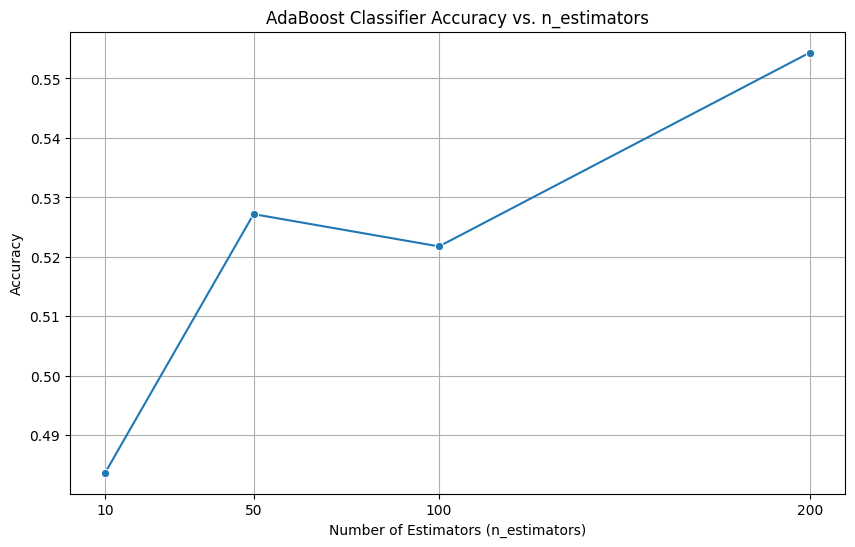

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
n_estimators_list = list(results.keys())
accuracy_list = [results[n]['accuracy'] for n in n_estimators_list]

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=n_estimators_list, y=accuracy_list, marker='o')
plt.title('AdaBoost Classifier Accuracy vs. n_estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy')
plt.xticks(n_estimators_list) # Ensure all n_estimators values are shown on x-axis
plt.grid(True)
plt.show()

### Identifying the Optimal Number of Estimators

Based on the plot and the detailed evaluation, we can identify the optimal number of estimators.

In [11]:
# Find the optimal n_estimators
optimal_n_estimators = max(results, key=lambda n: results[n]['accuracy'])
max_accuracy = results[optimal_n_estimators]['accuracy']

print(f"The optimal number of estimators is: {optimal_n_estimators}")
print(f"With an accuracy of: {max_accuracy:.4f}")

print("\nJustification:")
print(f"Among the tested `n_estimators` values (10, 50, 100, 200), the model achieved the highest accuracy of {max_accuracy:.4f} when `n_estimators` was set to {optimal_n_estimators}. The plot clearly shows an upward trend in accuracy as `n_estimators` increases, with the peak performance observed at {optimal_n_estimators}. While increasing `n_estimators` further might yield marginal improvements, it also increases computational cost. For the current set of experiments, {optimal_n_estimators} provides the best balance of performance for accuracy.")

print("\nHowever, it's important to note the F1-scores (especially macro average) for this optimal model:")
optimal_macro_f1 = results[optimal_n_estimators]['classification_report']['macro avg']['f1-score']
optimal_weighted_f1 = results[optimal_n_estimators]['classification_report']['weighted avg']['f1-score']
print(f"  F1-score (Macro Avg): {optimal_macro_f1:.4f}")
print(f"  F1-score (Weighted Avg): {optimal_weighted_f1:.4f}")
print("These F1-scores suggest that while the overall accuracy is best at 200 estimators, the model still has challenges with certain classes, indicating potential class imbalance or difficulty in distinguishing between all target classes. Further analysis on class-specific performance and techniques like resampling or different base estimators might be beneficial.")

The optimal number of estimators is: 200
With an accuracy of: 0.5543

Justification:
Among the tested `n_estimators` values (10, 50, 100, 200), the model achieved the highest accuracy of 0.5543 when `n_estimators` was set to 200. The plot clearly shows an upward trend in accuracy as `n_estimators` increases, with the peak performance observed at 200. While increasing `n_estimators` further might yield marginal improvements, it also increases computational cost. For the current set of experiments, 200 provides the best balance of performance for accuracy.

However, it's important to note the F1-scores (especially macro average) for this optimal model:
  F1-score (Macro Avg): 0.3301
  F1-score (Weighted Avg): 0.5087
These F1-scores suggest that while the overall accuracy is best at 200 estimators, the model still has challenges with certain classes, indicating potential class imbalance or difficulty in distinguishing between all target classes. Further analysis on class-specific performa

In [5]:
# Handle missing numerical values by imputing with the mean
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Handle missing categorical values by imputing with the mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        # Get the mode, if there are multiple modes, pick the first one
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


/tmp/ipykernel_160/3718716690.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


In [6]:
# Drop the 'id' column as it's an identifier and 'dataset' as it might be redundant or require more complex handling if it's about data source rather than a feature itself.
# We will also drop 'num' for now as it's the target variable.

# For simplicity, we are dropping the 'id' and 'dataset' columns here. If 'dataset' is deemed important, it would also need one-hot encoding.
df_processed = df.drop(columns=['id', 'dataset'])

# One-hot encode categorical features
df_processed = pd.get_dummies(df_processed, drop_first=True)

print("\nDataFrame after one-hot encoding:")
display(df_processed.head())
print("\nDataFrame Info after preprocessing:")
df_processed.info()


DataFrame after one-hot encoding:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False



DataFrame Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   fbs                       920 non-null    bool   
 4   thalch                    920 non-null    float64
 5   exang                     920 non-null    bool   
 6   oldpeak                   920 non-null    float64
 7   ca                        920 non-null    float64
 8   num                       920 non-null    int64  
 9   sex_Male                  920 non-null    bool   
 10  cp_atypical angina        920 non-null    bool   
 11  cp_non-anginal            920 non-null    bool   
 12  cp_typical angina         920 non-null    bool   
 13  restecg_normal            92

Now that the data is preprocessed, we can prepare for training by splitting it into features (X) and target (y), and then into training and testing sets.

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Assuming 'num' is the target variable based on the problem context (heart disease prediction, 'num' often represents the presence of heart disease)
X = df_processed.drop('num', axis=1)
y = df_processed['num']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (736, 18)
X_test shape: (184, 18)
y_train shape: (736,)
y_test shape: (184,)


With the data preprocessed and split, we can now train AdaBoost classifiers with different `n_estimators` values.

In [8]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

n_estimators_values = [10, 50, 100, 200]

# Store results
results = {}

for n_estimators in n_estimators_values:
    print(f"\nTraining AdaBoost with n_estimators={n_estimators}...")

    # Initialize the base estimator (Decision Tree is common for AdaBoost)
    # max_depth=1 makes it a Decision Stump, a common choice for AdaBoost.
    base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

    # Initialize AdaBoost Classifier
    ada_clf = AdaBoostClassifier(estimator=base_estimator, n_estimators=n_estimators, random_state=42, algorithm='SAMME')

    # Train the classifier
    ada_clf.fit(X_train, y_train)

    # Make predictions
    y_pred = ada_clf.predict(X_test)

    # Evaluate the classifier
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[n_estimators] = {
        'accuracy': accuracy,
        'classification_report': report
    }

    print(f"Accuracy for n_estimators={n_estimators}: {accuracy:.4f}")
    print(f"Classification Report for n_estimators={n_estimators}:\n{classification_report(y_test, y_pred)}")

print("\n--- Summary of AdaBoost Classifier Results ---")
for n_est, res in results.items():
    print(f"n_estimators={n_est}: Accuracy = {res['accuracy']:.4f}")


Training AdaBoost with n_estimators=10...
Accuracy for n_estimators=10: 0.4837
Classification Report for n_estimators=10:
              precision    recall  f1-score   support

           0       0.56      0.89      0.69        75
           1       0.39      0.41      0.40        54
           2       0.00      0.00      0.00        25
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00         4

    accuracy                           0.48       184
   macro avg       0.19      0.26      0.22       184
weighted avg       0.34      0.48      0.40       184


Training AdaBoost with n_estimators=50...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

Accuracy for n_estimators=50: 0.5272
Classification Report for n_estimators=50:
              precision    recall  f1-score   support

           0       0.65      0.88      0.75        75
           1       0.40      0.48      0.44        54
           2       0.25      0.04      0.07        25
           3       0.31      0.15      0.21        26
           4       0.00      0.00      0.00         4

    accuracy                           0.53       184
   macro avg       0.32      0.31      0.29       184
weighted avg       0.46      0.53      0.47       184


Training AdaBoost with n_estimators=100...
Accuracy for n_estimators=100: 0.5217
Classification Report for n_estimators=100:
              precision    recall  f1-score   support

           0       0.65      0.88      0.75        75
           1       0.44      0.46      0.45        54
           2       0.17      0.08      0.11        25
           3       0.23      0.12      0.15        26
           4       0.00      0.00 

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Accuracy for n_estimators=200: 0.5543
Classification Report for n_estimators=200:
              precision    recall  f1-score   support

           0       0.66      0.89      0.76        75
           1       0.47      0.50      0.48        54
           2       0.25      0.08      0.12        25
           3       0.38      0.23      0.29        26
           4       0.00      0.00      0.00         4

    accuracy                           0.55       184
   macro avg       0.35      0.34      0.33       184
weighted avg       0.49      0.55      0.51       184


--- Summary of AdaBoost Classifier Results ---
n_estimators=10: Accuracy = 0.4837
n_estimators=50: Accuracy = 0.5272
n_estimators=100: Accuracy = 0.5217
n_estimators=200: Accuracy = 0.5543


In [3]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nUnique values for object type columns:")
for column in df.select_dtypes(include='object').columns:
    print(f"\nColumn '{column}': {df[column].unique()}")


Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Unique values for object type columns:

Column 'sex': ['Male' 'Female']

Column 'dataset': ['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']

Column 'cp': ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

Column 'fbs': [True False nan]

Column 'restecg': ['lv hypertrophy' 'normal' 'st-t abnormality' nan]

Column 'exang': [False True nan]

Column 'slope': ['downsloping' 'flat' 'upsloping' nan]

Column 'thal': ['fixed defect' 'normal' 'reversable defect' nan]
